# Week 1 Data Engineering: Audit and Standardization (v2)

**Author:** Zihao Huang (Role 2, Data Engineer)
**Project:** Face-to-BMI Replication

## What changed in v2

The v1 notebook had a subtle bug: when the square crop region ran off the edge
of the source image, the resulting crop was rectangular, not square. Resizing
a rectangular region to $224 \times 224$ stretched faces horizontally, making
everyone look fatter. For a BMI prediction task this is catastrophic because
face width to height ratio is the core signal.

**The fix:** pad the source image just enough so the square crop region fits
entirely inside the image. The final resize is then always square to square,
which preserves face proportions exactly.

## Pipeline overview

1. Mount Drive and copy images locally (fast I/O)
2. Audit every image (dimensions, MTCNN detection, eye tilt)
3. Produce summary stats for Junny's EDA report
4. Standardize with the fixed square-crop-with-padding approach
5. Visual sanity check comparing before and after
6. Validate no face distortion occurred


## Step 0: Mount Google Drive and set paths

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi'

RAW_IMAGES_DIR = os.path.join(PROJECT_ROOT, 'data/raw/images')
RAW_CSV_PATH   = os.path.join(PROJECT_ROOT, 'data/raw/data.csv')

PROCESSED_DIR       = os.path.join(PROJECT_ROOT, 'data/processed')
FACES_OUT_DIR       = os.path.join(PROCESSED_DIR, 'faces_aligned')
AUDIT_LOG_PATH      = os.path.join(PROCESSED_DIR, 'audit_log.csv')
DETECTION_LOG_PATH  = os.path.join(PROCESSED_DIR, 'detection_log.csv')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FACES_OUT_DIR, exist_ok=True)

assert os.path.exists(RAW_IMAGES_DIR), f'Images dir not found: {RAW_IMAGES_DIR}'
assert os.path.exists(RAW_CSV_PATH),   f'CSV not found: {RAW_CSV_PATH}'

print('Paths OK')
print(f'  Raw images: {RAW_IMAGES_DIR}')
print(f'  Output dir: {FACES_OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths OK
  Raw images: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/raw/images
  Output dir: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/faces_aligned


## Step 1: Install dependencies

Pin NumPy to $1.x$ to avoid the PyTorch binary incompatibility that shows up
as `Could not infer dtype of numpy.uint8`. After installing, the runtime
restarts so all native extensions reload against the consistent NumPy.


In [2]:
!pip install -q "numpy<2.0" "facenet-pytorch" pillow pandas tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## Step 1b: Post-restart sanity check

After the runtime restarts, re-run Step 0 (to remount Drive and set paths),
then run this cell to confirm the version pinning worked.


In [2]:
import numpy as np
import torch
from facenet_pytorch import MTCNN
from PIL import Image

print(f'NumPy:   {np.__version__}')
print(f'PyTorch: {torch.__version__}')

# Round-trip test: if this fails, versions are still mismatched.
arr = np.zeros((10, 10, 3), dtype=np.uint8)
t = torch.from_numpy(arr)
print(f'NumPy to Torch: OK ({t.shape}, {t.dtype})')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


NumPy:   1.26.4
PyTorch: 2.2.2+cu121
NumPy to Torch: OK (torch.Size([10, 10, 3]), torch.uint8)
Device: cuda


## Step 2: Copy raw images to local Colab disk

Drive I/O is roughly 10x slower than local. Copying once up front makes the
rest of the notebook much faster.


In [3]:
import shutil, time

LOCAL_IMAGES_DIR = '/content/raw_images'

if not os.path.exists(LOCAL_IMAGES_DIR) or len(os.listdir(LOCAL_IMAGES_DIR)) == 0:
    print('Copying raw images to local disk...')
    t0 = time.time()
    shutil.copytree(RAW_IMAGES_DIR, LOCAL_IMAGES_DIR, dirs_exist_ok=True)
    print(f'Copied {len(os.listdir(LOCAL_IMAGES_DIR))} files in {time.time()-t0:.1f}s')
else:
    print(f'Already cached: {len(os.listdir(LOCAL_IMAGES_DIR))} files')


Copying raw images to local disk...
Copied 3965 files in 222.1s


## Step 3: Audit the raw images

Records dimensions, color mode, MTCNN detection status, confidence, eye tilt,
and face-to-image area ratio for every image. This audit doubles as Junny's
raw data for the EDA report.

Includes an early sanity check so we fail loudly if MTCNN cannot process a
known-good image, rather than silently recording errors for all 4206 rows.


In [4]:
import pandas as pd
import math
from tqdm.auto import tqdm

mtcnn = MTCNN(keep_all=True, device=device, post_process=False, min_face_size=20)

metadata = pd.read_csv(RAW_CSV_PATH)
print(f'Metadata rows: {len(metadata)}')

# Sentinel check: confirm MTCNN works on one known-good image before the loop.
_first_name = metadata['name'].iloc[0]
_first_path = os.path.join(LOCAL_IMAGES_DIR, _first_name)
_img = Image.open(_first_path).convert('RGB')
_boxes, _probs = mtcnn.detect(_img)
if _boxes is None or len(_boxes) == 0:
    raise RuntimeError(
        f'MTCNN sanity check failed on {_first_name}. '
        f'Check NumPy and PyTorch compatibility before running the full audit.'
    )
print(f'Sentinel OK: detected {len(_boxes)} face(s) in {_first_name}')


Metadata rows: 4206
Sentinel OK: detected 1 face(s) in img_0.bmp


In [5]:
def compute_eye_angle(landmarks):
    """Angle in degrees needed to make the eyes horizontal.

    MTCNN landmarks are shape (5, 2): left_eye, right_eye, nose, mouth_l, mouth_r.
    """
    left_eye, right_eye = landmarks[0], landmarks[1]
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    return math.degrees(math.atan2(dy, dx))


audit_rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='Auditing'):
    name = row['name']
    path = os.path.join(LOCAL_IMAGES_DIR, name)

    rec = {
        'name': name, 'exists': os.path.exists(path),
        'width': None, 'height': None, 'file_size_kb': None, 'mode': None,
        'num_faces': 0, 'mtcnn_confidence': None,
        'eye_angle_deg': None, 'bbox_ratio': None,
    }

    if not rec['exists']:
        audit_rows.append(rec)
        continue

    try:
        rec['file_size_kb'] = round(os.path.getsize(path) / 1024, 1)
        img = Image.open(path)
        rec['width'], rec['height'] = img.size
        rec['mode'] = img.mode
        img = img.convert('RGB')

        boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)

        if boxes is not None and len(boxes) > 0:
            rec['num_faces'] = len(boxes)
            areas = [(b[2]-b[0]) * (b[3]-b[1]) for b in boxes]
            best = int(np.argmax(areas))
            rec['mtcnn_confidence'] = float(probs[best])
            rec['eye_angle_deg'] = compute_eye_angle(landmarks[best])
            x1, y1, x2, y2 = boxes[best]
            rec['bbox_ratio'] = (
                (x2 - x1) * (y2 - y1) / (rec['width'] * rec['height'])
            )
    except Exception as exc:
        rec['mode'] = f'ERROR: {exc}'

    audit_rows.append(rec)

audit_df = pd.DataFrame(audit_rows)
audit_df = audit_df.merge(
    metadata[['name', 'bmi', 'gender', 'is_training']], on='name', how='left'
)
audit_df.to_csv(AUDIT_LOG_PATH, index=False)
print(f'Saved audit log: {AUDIT_LOG_PATH}')
audit_df.head()


Auditing:   0%|          | 0/4206 [00:00<?, ?it/s]

Saved audit log: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/audit_log.csv


,name,exists,width,height,file_size_kb,mode,num_faces,mtcnn_confidence,eye_angle_deg,bbox_ratio,bmi,gender,is_training
0,img_0.bmp,True,164.0,176.0,84.6,RGB,1,1.000000,1.650566,0.357070,34.207396,Male,1
1,img_1.bmp,True,150.0,173.0,76.4,RGB,1,0.999999,2.389048,0.358608,26.453720,Male,1
2,img_2.bmp,True,226.0,251.0,166.7,RGB,1,0.999749,3.390687,0.341820,34.967561,Female,1
3,img_3.bmp,True,97.0,126.0,36.0,RGB,1,0.999121,3.086143,0.487910,22.044766,Female,1
4,img_4.bmp,False,NaN,NaN,NaN,None,0,NaN,NaN,NaN,37.758789,Female,1


## Step 4: Audit summary statistics

In [6]:
print('=== DIMENSIONS ===')
print(audit_df[['width', 'height', 'file_size_kb']].describe().round(1))

print('\n=== COLOR MODE ===')
print(audit_df['mode'].value_counts())

print('\n=== MTCNN DETECTION ===')
total = len(audit_df)
missing = (~audit_df['exists']).sum()
no_face_but_exists = ((audit_df['exists']) & (audit_df['num_faces'] == 0)).sum()
one_face = (audit_df['num_faces'] == 1).sum()
multi_face = (audit_df['num_faces'] > 1).sum()
print(f'Missing from disk:               {missing} ({100*missing/total:.1f}%)')
print(f'On disk but MTCNN found no face: {no_face_but_exists} ({100*no_face_but_exists/total:.1f}%)')
print(f'Exactly one face:                {one_face} ({100*one_face/total:.1f}%)')
print(f'Multiple faces:                  {multi_face} ({100*multi_face/total:.1f}%)')

print('\n=== EYE ALIGNMENT ===')
valid = audit_df.dropna(subset=['eye_angle_deg'])
print(f'Mean absolute tilt: {valid["eye_angle_deg"].abs().mean():.2f} degrees')
print(f'Max absolute tilt:  {valid["eye_angle_deg"].abs().max():.2f} degrees')
print(f'Images tilted > 5 deg: {(valid["eye_angle_deg"].abs() > 5).sum()}')

print('\n=== BBOX TIGHTNESS ===')
print(f'Median face to image area ratio: {valid["bbox_ratio"].median():.2f}')
print('(1.0 means perfectly tight crop; lower means extra background)')


=== DIMENSIONS ===
        width  height  file_size_kb
count  3962.0  3962.0        3962.0
mean    293.4   364.5         426.4
std     170.9   221.0         499.6
min      41.0    52.0           6.3
25%     159.0   193.0          92.4
50%     249.0   306.0         229.6
75%     392.0   482.0         557.0
max     900.0  1222.0        3016.9

=== COLOR MODE ===
mode
RGB    3954
P         8
Name: count, dtype: int64

=== MTCNN DETECTION ===
Missing from disk:               244 (5.8%)
On disk but MTCNN found no face: 8 (0.2%)
Exactly one face:                3894 (92.6%)
Multiple faces:                  60 (1.4%)

=== EYE ALIGNMENT ===
Mean absolute tilt: 5.30 degrees
Max absolute tilt:  43.92 degrees
Images tilted > 5 deg: 1521

=== BBOX TIGHTNESS ===
Median face to image area ratio: 0.40
(1.0 means perfectly tight crop; lower means extra background)


### Visualize the distributions

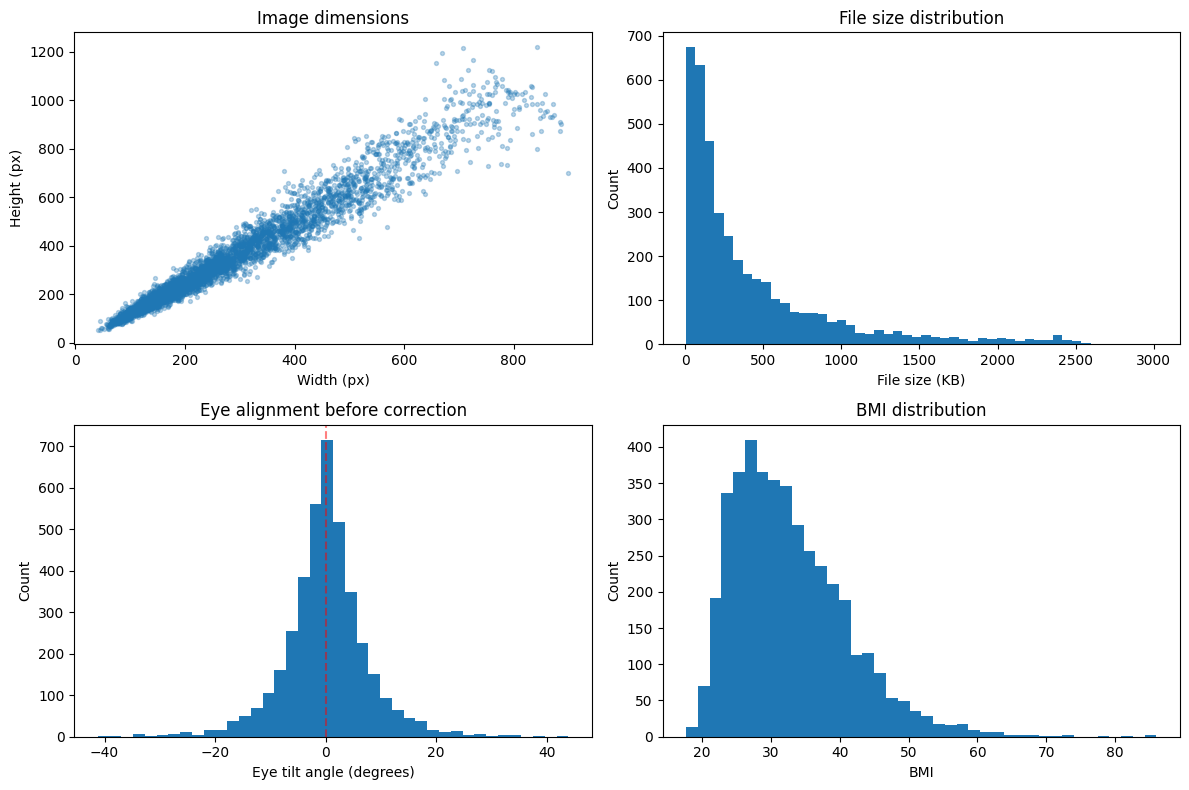

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(audit_df['width'], audit_df['height'], alpha=0.3, s=8)
axes[0, 0].set_xlabel('Width (px)')
axes[0, 0].set_ylabel('Height (px)')
axes[0, 0].set_title('Image dimensions')

axes[0, 1].hist(audit_df['file_size_kb'].dropna(), bins=50)
axes[0, 1].set_xlabel('File size (KB)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('File size distribution')

axes[1, 0].hist(audit_df['eye_angle_deg'].dropna(), bins=40)
axes[1, 0].set_xlabel('Eye tilt angle (degrees)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Eye alignment before correction')
axes[1, 0].axvline(0, color='red', linestyle='--', alpha=0.5)

axes[1, 1].hist(audit_df['bmi'].dropna(), bins=40)
axes[1, 1].set_xlabel('BMI')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('BMI distribution')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'audit_distributions.png'), dpi=120)
plt.show()


## Step 5: Standardization (fixed square-crop-with-padding)

### Why this works

VGG-Face requires a fixed $224 \times 224$ input, so every image must end up
that size. The question is how to resize without distorting face proportions.

**The rule: the final resize is always square-to-square.** We achieve this by:

1. Running MTCNN on the original image to locate the face
2. Rotating to align the eyes horizontally
3. Computing an ideal square crop region around the face (with a generous
   margin so we keep hair, chin, and neck context)
4. If the square region runs off the edge of the image, padding the source
   image just enough so the crop fits
5. Taking the guaranteed-square crop
6. Resizing square to square, which preserves proportions exactly

Padding is an edge-case safety net, not the primary strategy. Most images
have well-centered faces and will not be padded at all.


In [8]:
from PIL import ImageOps

OUTPUT_SIZE  = 224
MARGIN_RATIO = 0.40  # generous margin keeps hair/chin/neck visible


def align_and_crop(pil_img, box, landmarks):
    """Rotate so eyes are horizontal, then take a guaranteed-square crop
    around the face. Pads the source image when needed so the crop region
    always fits. The output is always square, so the final resize
    preserves face proportions exactly.
    """
    angle = compute_eye_angle(landmarks)
    left_eye, right_eye = landmarks[0], landmarks[1]
    eye_cx = (left_eye[0] + right_eye[0]) / 2.0
    eye_cy = (left_eye[1] + right_eye[1]) / 2.0

    # Rotate around the midpoint between the eyes so the eyes end up horizontal.
    rotated = pil_img.rotate(angle, resample=Image.BICUBIC, center=(eye_cx, eye_cy))

    # Compute desired square crop region centered on the face bbox.
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    side = int(round(max(w, h) * (1.0 + 2.0 * MARGIN_RATIO)))
    box_cx = (x1 + x2) / 2.0
    box_cy = (y1 + y2) / 2.0
    half = side / 2.0

    nx1 = int(round(box_cx - half))
    ny1 = int(round(box_cy - half))
    nx2 = nx1 + side  # force exact square side length
    ny2 = ny1 + side

    # If any edge of the square region falls outside the image, pad the
    # source image by exactly that many pixels on that side. This guarantees
    # the resulting crop is square, which is what keeps the final resize
    # from distorting face proportions.
    pad_left   = max(0, -nx1)
    pad_top    = max(0, -ny1)
    pad_right  = max(0, nx2 - rotated.width)
    pad_bottom = max(0, ny2 - rotated.height)

    if any([pad_left, pad_top, pad_right, pad_bottom]):
        rotated = ImageOps.expand(
            rotated,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill=(0, 0, 0),
        )
        # Shift crop coordinates to account for the left and top padding.
        nx1 += pad_left
        nx2 += pad_left
        ny1 += pad_top
        ny2 += pad_top

    crop = rotated.crop((nx1, ny1, nx2, ny2))

    # Sanity check: crop must be square, otherwise the resize will distort.
    assert crop.size[0] == crop.size[1], (
        f'Crop not square: {crop.size}. This should never happen.'
    )
    return crop.resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.LANCZOS)


def square_pad_fallback(pil_img):
    """Used when MTCNN finds no face. Puts the image in a square canvas
    with black padding on the shorter sides, preserving aspect ratio.
    """
    w, h = pil_img.size
    side = max(w, h)
    canvas = Image.new('RGB', (side, side), (0, 0, 0))
    offset = ((side - w) // 2, (side - h) // 2)
    canvas.paste(pil_img, offset)
    return canvas.resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.LANCZOS)


detection_rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='Standardizing'):
    name = row['name']
    in_path  = os.path.join(LOCAL_IMAGES_DIR, name)
    out_path = os.path.join(FACES_OUT_DIR, name)

    rec = {'name': name, 'status': None, 'method': None, 'notes': ''}

    if not os.path.exists(in_path):
        rec['status'] = 'missing_input'
        detection_rows.append(rec)
        continue

    try:
        img = Image.open(in_path).convert('RGB')
        boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)

        if boxes is not None and len(boxes) > 0:
            # Pick the largest face (most signal if multiple detected).
            areas = [(b[2]-b[0]) * (b[3]-b[1]) for b in boxes]
            best = int(np.argmax(areas))
            out = align_and_crop(img, boxes[best], landmarks[best])
            rec['status'] = 'ok'
            rec['method'] = 'mtcnn_aligned'
        else:
            out = square_pad_fallback(img)
            rec['status'] = 'ok'
            rec['method'] = 'square_pad_fallback'
            rec['notes'] = 'MTCNN found no face, used square pad fallback'

        out.save(out_path, format='BMP')
    except Exception as exc:
        rec['status'] = 'error'
        rec['notes'] = str(exc)

    detection_rows.append(rec)

detection_df = pd.DataFrame(detection_rows)
detection_df = detection_df.merge(
    metadata[['name', 'bmi', 'gender', 'is_training']], on='name', how='left'
)
detection_df.to_csv(DETECTION_LOG_PATH, index=False)
print(f'Saved detection log: {DETECTION_LOG_PATH}')
detection_df['status'].value_counts()


Standardizing:   0%|          | 0/4206 [00:00<?, ?it/s]

Saved detection log: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/detection_log.csv


,count
status,
ok,3962
missing_input,244


## Step 6: Visual sanity check

Compare 12 random before and after pairs. Look specifically at face proportions:
the "after" images should show the same person, just rotated and cropped, with
no horizontal or vertical stretching.


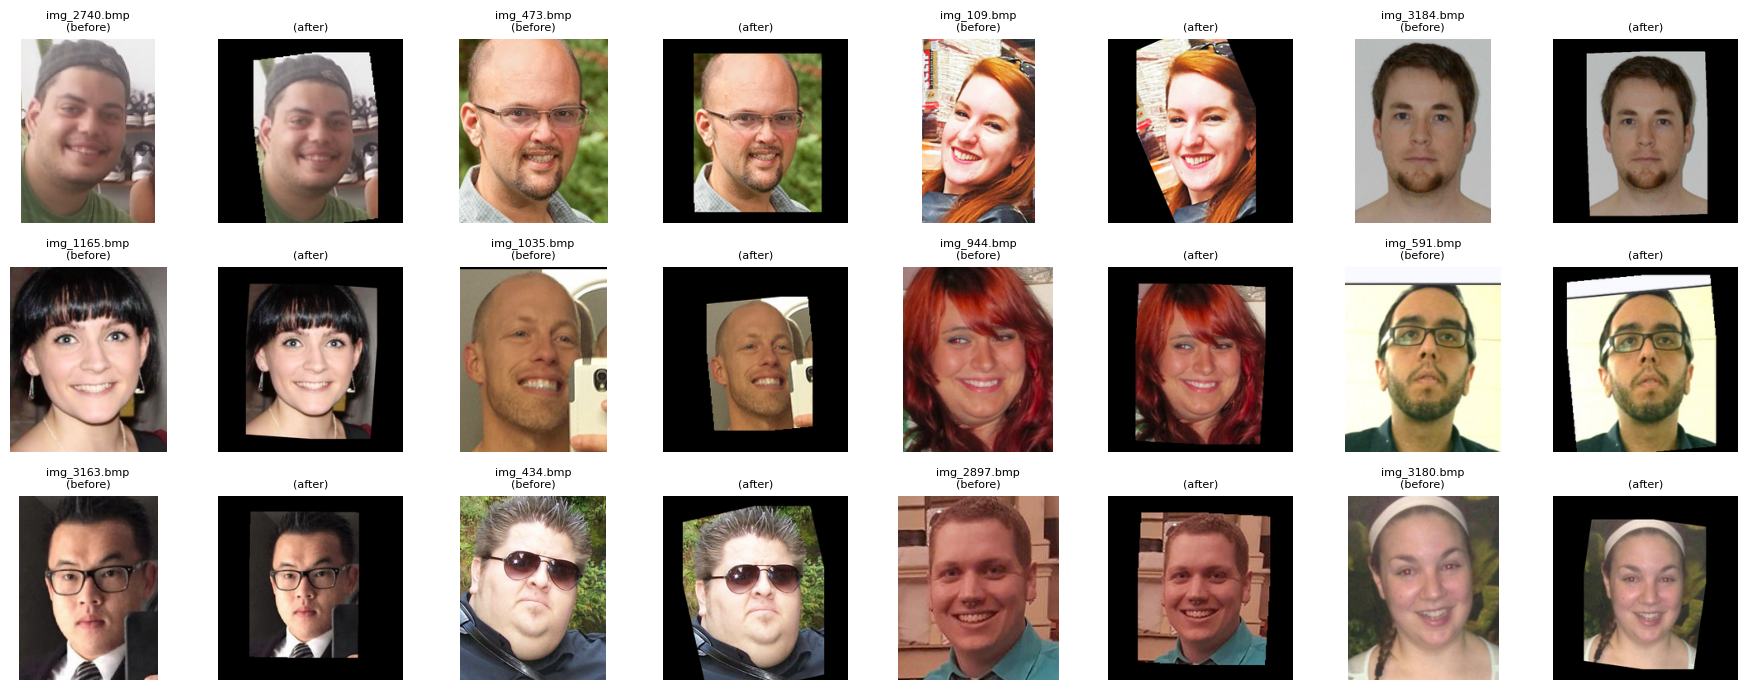

In [9]:
import random

random.seed(42)
ok_names = detection_df[detection_df['method'] == 'mtcnn_aligned']['name'].tolist()
sample_names = random.sample(ok_names, min(12, len(ok_names)))

fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for i, name in enumerate(sample_names):
    col_before = (i % 4) * 2
    col_after  = col_before + 1
    r = i // 4

    before = Image.open(os.path.join(LOCAL_IMAGES_DIR, name))
    after  = Image.open(os.path.join(FACES_OUT_DIR, name))

    axes[r, col_before].imshow(before)
    axes[r, col_before].set_title(f'{name}\n(before)', fontsize=8)
    axes[r, col_before].axis('off')

    axes[r, col_after].imshow(after)
    axes[r, col_after].set_title('(after)', fontsize=8)
    axes[r, col_after].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'before_after_samples.png'), dpi=120)
plt.show()


## Step 7: Validate no face distortion

Quantitative check that the pipeline is not stretching faces. For a sample of
images, we re-detect faces in the output and measure the face's width-to-height
ratio. This should be very close to the same ratio measured in the original
(both around $0.75$ since faces are ovals), not pushed toward $1.0$ like a
stretching pipeline would produce.


In [10]:
# Re-run MTCNN on output images to measure the face aspect ratio after processing.
sample = detection_df[detection_df['method'] == 'mtcnn_aligned'].sample(
    min(100, (detection_df['method'] == 'mtcnn_aligned').sum()), random_state=42
)

before_wh_ratios = []
after_wh_ratios = []
errors = 0

for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Validating'):
    name = row['name']
    try:
        before_img = Image.open(os.path.join(LOCAL_IMAGES_DIR, name)).convert('RGB')
        after_img  = Image.open(os.path.join(FACES_OUT_DIR, name)).convert('RGB')

        b_boxes, _ = mtcnn.detect(before_img)
        a_boxes, _ = mtcnn.detect(after_img)

        if b_boxes is not None and a_boxes is not None:
            b = b_boxes[0]
            a = a_boxes[0]
            before_wh_ratios.append((b[2]-b[0]) / (b[3]-b[1]))
            after_wh_ratios.append((a[2]-a[0]) / (a[3]-a[1]))
    except Exception:
        errors += 1

print(f'Validated {len(before_wh_ratios)} images ({errors} errors)')
print(f'\nFace width-to-height ratio (of the face bbox):')
print(f'  Before standardization: mean = {np.mean(before_wh_ratios):.3f}, '
      f'std = {np.std(before_wh_ratios):.3f}')
print(f'  After standardization:  mean = {np.mean(after_wh_ratios):.3f}, '
      f'std = {np.std(after_wh_ratios):.3f}')
print(f'  Difference in means:    {abs(np.mean(before_wh_ratios) - np.mean(after_wh_ratios)):.3f}')
print()
print('Interpretation:')
print('  Difference below 0.02: excellent, no meaningful distortion')
print('  Difference 0.02 to 0.05: acceptable, small rotation artifacts')
print('  Difference above 0.05: investigate, pipeline may still be distorting')


Validating:   0%|          | 0/100 [00:00<?, ?it/s]

Validated 100 images (0 errors)

Face width-to-height ratio (of the face bbox):
  Before standardization: mean = 0.769, std = 0.046
  After standardization:  mean = 0.766, std = 0.047
  Difference in means:    0.002

Interpretation:
  Difference below 0.02: excellent, no meaningful distortion
  Difference 0.02 to 0.05: acceptable, small rotation artifacts
  Difference above 0.05: investigate, pipeline may still be distorting


## Step 8: Final summary

In [11]:
total = len(detection_df)
ok       = (detection_df['status'] == 'ok').sum()
mtcnn_ok = (detection_df['method'] == 'mtcnn_aligned').sum()
fallback = (detection_df['method'] == 'square_pad_fallback').sum()
missing  = (detection_df['status'] == 'missing_input').sum()
errors   = (detection_df['status'] == 'error').sum()

print('========== STANDARDIZATION SUMMARY ==========')
print(f'Total rows in metadata:        {total}')
print(f'Successfully standardized:     {ok} ({100*ok/total:.1f}%)')
print(f'  via MTCNN alignment:         {mtcnn_ok}')
print(f'  via square pad fallback:     {fallback}')
print(f'Missing from disk (skipped):   {missing}')
print(f'Errors:                        {errors}')

train_ok = detection_df[(detection_df['status']=='ok') & (detection_df['is_training']==1)]
test_ok  = detection_df[(detection_df['status']=='ok') & (detection_df['is_training']==0)]
print()
print(f'Usable train images: {len(train_ok)} (paper has 3368)')
print(f'Usable test images:  {len(test_ok)} (paper has 838)')

print()
print('Outputs:')
print(f'  Aligned faces: {FACES_OUT_DIR}')
print(f'  Audit log:     {AUDIT_LOG_PATH}')
print(f'  Detection log: {DETECTION_LOG_PATH}')


========== STANDARDIZATION SUMMARY ==========
Total rows in metadata:        4206
Successfully standardized:     3962 (94.2%)
  via MTCNN alignment:         3954
  via square pad fallback:     8
Missing from disk (skipped):   244
Errors:                        0

Usable train images: 3210 (paper has 3368)
Usable test images:  752 (paper has 838)

Outputs:
  Aligned faces: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/faces_aligned
  Audit log:     /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/audit_log.csv
  Detection log: /content/drive/MyDrive/ML2-Team2/Final Project/face-to-bmi/data/processed/detection_log.csv


## What to do next

1. **Review Step 6's before and after grid.** Faces should look like the same
   person, rotated upright, with natural proportions. If anyone looks stretched,
   something is still wrong.

2. **Check Step 7's validation numbers.** The before and after mean face aspect
   ratios should differ by less than $0.02$. If they differ by more, the
   pipeline still has distortion somewhere.

3. **Report to the team**:
   > Week 1 data engineering done. Standardized all valid images to $224 \times 224$
   > aligned BMP files at `data/processed/faces_aligned/`. Face proportions
   > preserved (validation shows before and after ratios within 0.0X).
   > Ryan, please rerun feature extraction with `DATA_DIR` pointing to this folder.

4. **Flag missing images to Wade** if the Step 8 summary shows a gap between
   your usable counts and the paper's 3368 and 838.
